In [1]:
import torch 
import torch.nn as nn

In [2]:
import numpy as np

In [3]:
from basemodel import *

In [4]:
from data_handler import *

In [5]:
from optimizer import *

In [6]:
from fit import *

In [7]:
import matplotlib.pyplot as plt

In [8]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data.sampler import *

In [9]:
import cbs

In [10]:
from unet import Unet_sigmoid

In [11]:
from collections import OrderedDict

In [12]:
import unet_ein as ue

In [13]:
def save(path,results,names = ['normal','attack','disable','end','test']):
    for i in range(len(results)):
        np.save(path+names[i]+'.npy',results[i])

In [14]:
import pytorch_ssim

# Data

In [15]:
trn_ , val_ = split('../dataset/fuz attack/lka_can/normal/bin/',prc = 0.2, dataset_pct=  1, dim =(112,112), word_type=torch.float)
atk , _ = split('../dataset/fuz attack/lka_can/attack/bin/',prc = 0 , dataset_pct=  1, dim = (112,112), word_type=torch.float)

In [16]:
bs = 8
seq_len = 20
overlap=0

In [17]:
trn_dl = Sequence_dl( trn_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])
v4_val_dl = Sequence_dl( val_, bs=bs,seq_len=seq_len,overlap = overlap, num_workers=4,drop_last=True,dim=[112,112])

In [18]:
v4_anml_dl = Sequence_dl( atk, bs=bs,seq_len=seq_len,overlap =overlap,num_workers=4,drop_last=True,dim=[112,112])

In [19]:
dl =CombineDataLoader(trn_dl,v4_val_dl)

# Custom Loss

In [28]:
class binary:
    def __init__(self):
        self.ssim_loss = pytorch_ssim.SSIM(window_size = 11)
    def __call__(self,ip,tgt):
        tgt_lka,ip_lka= ip
        tgt_lka = tgt_lka [None,None,None,:]
        ip_lka = ip_lka [None,None,None,:]
        
        lka = self.ssim_loss(ip_lka,tgt_lka)
        return 1/(lka)

In [20]:
class binary:
    def __call__(self,ip,tgt):
        tgt_lka,ip_lka = ip
        
        #vis = nn.functional.binary_cross_entropy(ip_vis[:88],tgt_vis[:88])
        lka = nn.functional.binary_cross_entropy(ip_lka[:88],tgt_lka[:88])
        return lka

In [29]:
loss = binary()

# Model : Combined

In [37]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1])
        
        self.vis = torch.rand(88).cuda()
        self.lka = torch.rand(88).cuda()
        
        self.vis_compressor = nn.Sequential(nn.Linear(88,256*2),nn.PReLU(),nn.Dropout(0.1),nn.Linear(256*2,88*2))
        self.lka_compressor = nn.Sequential(nn.Linear(88,256*2),nn.PReLU(),nn.Dropout(0.1),nn.Linear(256*2,88*2))
        
        self.combined_signal_compressor = nn.Sequential(nn.Linear(88*2,256*4),
                                                        nn.Dropout(0.1),
                                                        nn.PReLU(),
                                                        nn.Linear(256*4,88*2),
                                                        nn.Dropout(0.1),
                                                        nn.PReLU(),
                                                        nn.Linear(88*2,88*1),
                                                        nn.Dropout(0.1),
                                                        nn.PReLU(),
                                                        nn.Linear(88*1,88*2))
        self.drop = nn.Dropout(0.1)
        self.flag_list = []
    def forward(self,x):        
        input_list = x.view(160,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:132] == self._289).sum(dim=1) // 12) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(160,-1)[vis_idx[0]][120:208]
        if lka_idx.size :
            self.lka = x.view(160,-1)[lka_idx[0]][120:208]
            
        #vis_reconstrunct = self.drop(self.vis_compressor(self.vis))
        #lka_reconstrunct = self.drop(self.lka_compressor(self.lka))
        cat = torch.cat([self.vis,self.lka])
        out = torch.sigmoid(self.drop(self.combined_signal_compressor(cat)))
        
        self.flag_list.append(self.lka.detach().cpu())
        return self.lka,self.vis,out[:88],out[88:]


In [38]:
m =  unet_seq(bs,seq_len).cuda()

In [39]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [40]:
trn_item = Validate(trn_dl)

In [41]:
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [42]:
learn.fit(m , opt , 4 , dl,loss  )

 99%|█████████▉| 252/255 [00:03<00:00, 65.61it/s, loss : 0.5470986139206659]3]

train Loss:  0.7387691736221313   validation loss:  0.5470603108406067
tensor(nan)


100%|█████████▉| 254/255 [00:03<00:00, 64.27it/s, loss : 0.542581032580278] 5]

train Loss:  0.673855721950531   validation loss:  0.5425624251365662
tensor(nan)


100%|██████████| 255/255 [00:03<00:00, 64.20it/s, loss : 0.5429953780828738]7]

train Loss:  0.664668619632721   validation loss:  0.5429953932762146
tensor(nan)


 99%|█████████▉| 253/255 [00:03<00:00, 64.77it/s, loss : 0.5378661626883646]7]

train Loss:  0.6533811092376709   validation loss:  0.5378112196922302
tensor(nan)


In [43]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

testing...


  0%|          | 3/608 [00:00<00:25, 23.83it/s]s]

testing...


 99%|█████████▉| 602/608 [00:09<00:00, 68.59it/s]

In [44]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
#c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

In [45]:
#index 203735 in the sheet

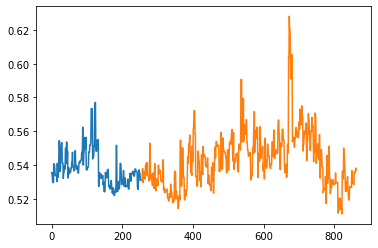

In [46]:
fig,ax = plt.subplots()
ax.plot(range(len(a)-1),list(a[1:]))
ax.plot(range(len(a),len(a)+len(b)),list(b))

In [ ]:
#d 8 EC F6 7C 9A 2F E3 93 10  Length = 219910 BitCount = 114 ID = 1707

In [ ]:
#d 8 08 F7 7C 7C 2F A4 A0 10  Length = 227910 BitCount = 118 ID = 1707
#d 8 08 F7 7C 7C 2F A4 A0 10  Length = 227910 BitCount = 118 ID = 1707
#d 8 09 D7 7C 74 0F A4 8E 10  Length = 223910 BitCount = 116 ID = 1707

In [ ]:
#d 8 CB F6 7C 7C 2F E4 9A 10  Length = 227910 BitCount = 118 ID = 1707
#d 8 CC E6 7C 7A 2F 63 93 10  Length = 217910 BitCount = 113 ID = 1707
#d 8 CC E6 7C 7E 2F 23 93 10  Length = 219910 BitCount = 114 ID = 1707

In [ ]:
#d 8 B3 07 75 12 10 09 4F 11  Length = 217910 BitCount = 113 ID = 1707
#d 8 B5 87 75 12 70 C9 5D 11  Length = 213910 BitCount = 111 ID = 1707
#d 8 B5 87 75 12 70 C9 5D 11  Length = 213910 BitCount = 111 ID = 1707

In [67]:
torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]).shape

torch.Size([88])

# Model : Toggle VIS

In [25]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(88).cuda()
        self.lka = torch.zeros(1).cuda()
        
        self.vis_compressor = nn.Sequential(nn.Linear(88,256*2),nn.PReLU(),nn.Dropout(0.1),nn.Linear(256*2,88*2))
        self.lka_compressor = nn.Sequential(nn.Linear(1,256*2),nn.PReLU(),nn.Dropout(0.1),nn.Linear(256*2,88))
        
        self.combined_signal_compressor = nn.Sequential(nn.Linear(88,256*4),
                                                        nn.Dropout(0.1),
                                                        nn.PReLU(),
                                                        nn.Linear(256*4,88//2),
                                                        nn.Dropout(0.1),
                                                        nn.PReLU(),
                                                        nn.Linear(88//2,88*1),
                                                        nn.Dropout(0.1),
                                                        nn.PReLU(),
                                                        nn.Linear(88*1,88*2))
        self.drop = nn.Dropout(0.1)
        self.flag_list = []
    def forward(self,x):        
        input_list = x.view(160,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(160,-1)[vis_idx[0]][120:208]
        if lka_idx.size :
            if self.lka: 
                print('yes')
                self.lka = torch.zeros(1).cuda()
            else:
                self.lka = torch.ones(1).cuda().cuda()
            
            
        #vis_reconstrunct = self.drop(self.vis_compressor(self.vis))
        lka_reconstrunct = self.drop(self.lka_compressor(self.lka))
        
        #cat = torch.cat([self.vis,lka_reconstrunct])
        cat = torch.relu(self.vis + self.lka)
        out = torch.sigmoid(self.drop(self.combined_signal_compressor(cat)))
        
        self.flag_list.append(self.lka.detach().cpu())
        return self.lka,self.vis,out[:88],out[88:]


In [26]:
m =  unet_seq(bs,seq_len).cuda()

In [27]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [28]:
trn_item = Validate(trn_dl)

In [29]:
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [30]:
learn.fit(m , opt , 2 , dl,loss  )

 98%|█████████▊| 249/255 [00:03<00:00, 64.33it/s, loss : 0.38698461448332394]]

train Loss:  0.9029080271720886   validation loss:  0.3868783414363861
tensor(nan)


 37%|███▋      | 380/1023 [00:06<00:10, 61.90it/s, loss : 0.4064397309955798] 

yes


 98%|█████████▊| 249/255 [00:03<00:00, 65.32it/s, loss : 0.5445105004980861]5]

train Loss:  0.6509531140327454   validation loss:  0.5443268418312073
tensor(nan)


In [31]:
m.lka = torch.zeros_like(m.lka).cuda()

In [32]:
trn_item.evaluate(model = m , crit = loss)

testing...


100%|█████████▉| 1020/1023 [00:15<00:00, 65.89it/s]

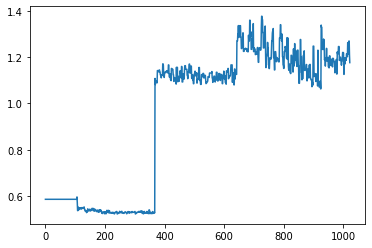

In [33]:
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))

In [34]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

  1%|          | 3/255 [00:00<00:08, 28.71it/s]

testing...


  0%|          | 1/608 [00:00<01:05,  9.24it/s]s]

testing...


  5%|▌         | 33/608 [00:00<00:21, 27.25it/s]

yes


100%|██████████| 608/608 [00:09<00:00, 70.65it/s]

In [35]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
#c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

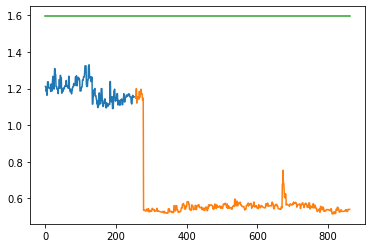

In [36]:
fig,ax = plt.subplots()
ax.plot(range(len(a)-1),list(a[1:]))
ax.plot(range(len(a),len(a)+len(b)),list(b))
ax.plot(range(len(a)+len(b)), [a.max()+ a.max()*0.2]*(len(a)+len(b)))

# Model : predective model for VIS

In [21]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1])
        
        self.vis = torch.rand(88).cuda()
        self.lka = torch.rand(88).cuda()
        
        self.vis_compressor = nn.Sequential(nn.Linear(88,256*2),
                                            nn.PReLU(),
                                            nn.Dropout(0.1),
                                            nn.Linear(256*2,88))
        
        self.drop = nn.Dropout(0.1)
        self.previous_vis = torch.zeros(88).cuda()
        self.flag_list = []
    def forward(self,x):        
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:132] == self._289).sum(dim=1) // 12) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
        if lka_idx.size :
            self.lka = x.view(80,-1)[lka_idx[0]][120:208]
            
        predected_vis = self.vis_compressor(self.drop(self.previous_vis))
        torch.sigmoid_(predected_vis)
        
        self.previous_vis = self.vis.detach().data
        
        return self.lka,self.vis,None,predected_vis


In [22]:
m =  unet_seq(bs,seq_len).cuda()

In [23]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [24]:
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [25]:
learn.fit(m , opt , 8 , dl,loss  )

 98%|█████████▊| 507/515 [00:03<00:00, 132.01it/s, loss : 0.2741799439198872] 5]

train Loss:  0.19687479734420776   validation loss:  0.2749856412410736
tensor(nan)


100%|█████████▉| 513/515 [00:03<00:00, 128.12it/s, loss : 0.24659178735684698]2]

train Loss:  0.146120086312294   validation loss:  0.24673821032047272
tensor(nan)


 98%|█████████▊| 507/515 [00:04<00:00, 131.38it/s, loss : 0.22720517491447856]7]

...

train Loss:  0.09982600808143616   validation loss:  0.1866007149219513
tensor(nan)


 97%|█████████▋| 502/515 [00:03<00:00, 122.65it/s, loss : 0.17727772078191142]] 

train Loss:  0.09660468250513077   validation loss:  0.17764721810817719
tensor(nan)


 97%|█████████▋| 500/515 [00:03<00:00, 131.78it/s, loss : 0.16726890563964844]6]

train Loss:  0.09383309632539749   validation loss:  0.1675615757703781
tensor(nan)


In [26]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

testing...


  1%|          | 9/1224 [00:00<00:14, 84.72it/s]s]

testing...


 99%|█████████▉| 1213/1224 [00:09<00:00, 130.77it/s]

In [27]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
#c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

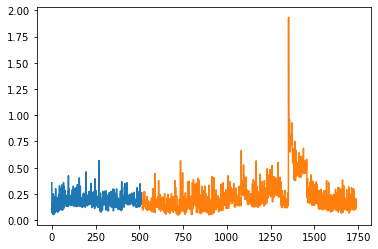

In [28]:
fig,ax = plt.subplots()
ax.plot(range(len(a)-1),list(a[1:]))
ax.plot(range(len(a),len(a)+len(b)),list(b))

# Model : predective model for VIS with history

In [34]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1])
        
        self.vis = torch.rand(88).cuda()
        self.lka = torch.rand(88).cuda()
        
        self.vis_compressor = nn.Sequential(nn.Linear(88*2,256*2),
                                            nn.PReLU(),
                                            nn.Dropout(0.1),
                                            nn.Linear(256*2,88))
        
        self.drop = nn.Dropout(0.1)
        self.previous_vis = torch.zeros(88).cuda()
        self.previous_states = torch.zeros(88).cuda()
        self.flag_list = []
        
        self.previous_states_conv = nn.Conv1d(2,1,(1))
    def forward(self,x):        
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:132] == self._289).sum(dim=1) // 12) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
        if lka_idx.size :
            self.lka = x.view(80,-1)[lka_idx[0]][120:208]
        
        #Get the history of vis from previous vis and all the past frames
        history = self.previous_states_conv(torch.stack([self.previous_states,self.previous_vis]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        predected_vis = self.vis_compressor(self.drop(torch.cat([self.previous_vis,history])))
        torch.sigmoid_(predected_vis)
        
        self.previous_vis = self.vis.detach().data
        self.previous_states = history.detach().data
        
        return self.lka,self.vis,None,predected_vis


In [35]:
m =  unet_seq(bs,seq_len).cuda()

In [36]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [37]:
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [38]:
learn.fit(m , opt , 8 , dl,loss  )

 97%|█████████▋| 501/515 [00:03<00:00, 126.88it/s, loss : 0.2770771018997162] ] 

train Loss:  0.1977497935295105   validation loss:  0.27852925658226013
tensor(nan)


 99%|█████████▊| 508/515 [00:03<00:00, 125.83it/s, loss : 0.25503350806048536]3]

train Loss:  0.14714185893535614   validation loss:  0.25571131706237793
tensor(nan)


 98%|█████████▊| 507/515 [00:04<00:00, 126.92it/s, loss : 0.23601200923882057]5]

...

train Loss:  0.092979297041893   validation loss:  0.19265145063400269
tensor(nan)


 97%|█████████▋| 501/515 [00:03<00:00, 135.28it/s, loss : 0.18339106089578655]7]

train Loss:  0.0892711654305458   validation loss:  0.1836833655834198
tensor(nan)


 99%|█████████▉| 512/515 [00:04<00:00, 129.11it/s, loss : 0.17735429108142853]5]

train Loss:  0.08685550093650818   validation loss:  0.17735090851783752
tensor(nan)


In [39]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

testing...


  1%|          | 9/1224 [00:00<00:14, 85.41it/s]s]

testing...


 99%|█████████▉| 1211/1224 [00:09<00:00, 120.65it/s]

In [40]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
#c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

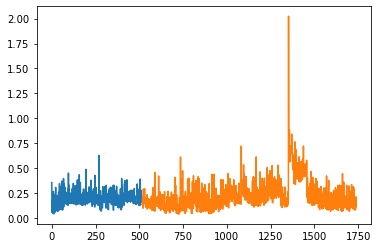

In [41]:
fig,ax = plt.subplots()
ax.plot(range(len(a)-1),list(a[1:]))
ax.plot(range(len(a),len(a)+len(b)),list(b))

In [50]:
b

tensor([0.1656, 0.1657, 0.1657,  ..., 0.1992, 0.1081, 0.2134])

# Model : predective model for VIS with history with current lka

In [42]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1])
        
        self.vis = torch.rand(88).cuda()
        self.lka = torch.rand(88).cuda()
        
        self.vis_compressor = nn.Sequential(nn.Linear(88*3,256*4),
                                            nn.PReLU(),
                                            nn.Dropout(0.1),
                                            nn.Linear(256*4,88))
        
        self.drop = nn.Dropout(0.1)
        self.previous_vis = torch.zeros(88).cuda()
        self.previous_states = torch.zeros(88).cuda()
        self.flag_list = []
        
        self.previous_states_conv = nn.Conv1d(2,1,(1))
    def forward(self,x):        
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:132] == self._289).sum(dim=1) // 12) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
        if lka_idx.size :
            self.lka = x.view(80,-1)[lka_idx[0]][120:208]
        
        #Get the history of vis from previous vis and all the past frames
        history = self.previous_states_conv(torch.stack([self.previous_states,self.previous_vis]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        predected_vis = self.vis_compressor(self.drop(torch.cat([self.previous_vis,history,self.lka])))
        torch.sigmoid_(predected_vis)
        
        self.previous_vis = self.vis.detach().data
        self.previous_states = history.detach().data
        
        return self.lka,self.vis,None,predected_vis


In [43]:
m =  unet_seq(bs,seq_len).cuda()

In [44]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [45]:
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [46]:
learn.fit(m , opt , 8 , dl,loss  )

 97%|█████████▋| 501/515 [00:03<00:00, 125.14it/s, loss : 0.298954215592253]  3]

train Loss:  0.17718034982681274   validation loss:  0.3010556101799011
tensor(nan)


100%|██████████| 515/515 [00:04<00:00, 129.43it/s, loss : 0.27059569127351335]7]

train Loss:  0.13168856501579285   validation loss:  0.2705956995487213
tensor(nan)


 98%|█████████▊| 507/515 [00:03<00:00, 121.29it/s, loss : 0.2512355556149454] 9]

...

train Loss:  0.08715745061635971   validation loss:  0.2183288335800171
tensor(nan)


 98%|█████████▊| 505/515 [00:03<00:00, 130.00it/s, loss : 0.2092146165300124] 4]

train Loss:  0.08489439636468887   validation loss:  0.2103196382522583
tensor(nan)


 99%|█████████▊| 508/515 [00:03<00:00, 131.92it/s, loss : 0.19801375621885764]5]

train Loss:  0.08363360166549683   validation loss:  0.1984446942806244
tensor(nan)


In [47]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

testing...


  1%|          | 11/1224 [00:00<00:11, 109.06it/s]

testing...


 99%|█████████▉| 1211/1224 [00:09<00:00, 125.72it/s]

In [48]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
#c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

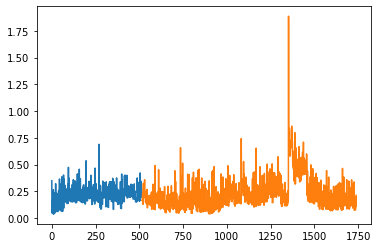

In [49]:
fig,ax = plt.subplots()
ax.plot(range(len(a)-1),list(a[1:]))
ax.plot(range(len(a),len(a)+len(b)),list(b))

# Model : predective model for LKA with history with current VIS

In [80]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1])
        
        self.vis = torch.rand(88).cuda()
        self.lka = torch.rand(88).cuda()
        
        self.lka_compressor = nn.Sequential(nn.Linear(88*3,256*4),
                                            nn.PReLU(),
                                            nn.Dropout(0.1),
                                            nn.Linear(256*4,88))
        
        self.drop = nn.Dropout(0.1)
        self.previous_lka = torch.zeros(88).cuda()
        self.previous_states = torch.zeros(88).cuda()
        self.flag_list = []
        self.predection = []
        self.previous_states_conv = nn.Conv1d(2,1,(1))
    def forward(self,x):        
        input_list = x.view(80,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:132] == self._289).sum(dim=1) // 12) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(80,-1)[vis_idx[0]][120:208]
        if lka_idx.size :
            self.lka = x.view(80,-1)[lka_idx[0]][120:208]

        
        #Get the history of vis from previous vis and all the past frames
        history = self.previous_states_conv(torch.stack([self.previous_states,self.previous_lka]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        predected_lka = self.lka_compressor(self.drop(torch.cat([self.previous_lka,history,self.vis])))
        torch.sigmoid_(predected_lka)
        
        self.previous_lka = self.lka.detach().data
        self.previous_states = history.detach().data
        
        self.flag_list.append(self.lka.cpu().data)
        self.predection.append(predected_lka.cpu().data)
        return self.lka,self.vis,predected_lka,None


In [81]:
m =  unet_seq(bs,seq_len).cuda()

In [82]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [89]:
trn_item = Validate(trn_dl)

In [83]:
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [84]:
learn.fit(m , opt , 8 , dl,loss  )

 98%|█████████▊| 503/515 [00:04<00:00, 123.65it/s, loss : 2.9401644457050156e-05]

train Loss:  0.017481232061982155   validation loss:  2.9143173378542997e-05
tensor(nan)


 99%|█████████▊| 508/515 [00:04<00:00, 123.77it/s, loss : 7.026245373880535e-06]96]

train Loss:  0.0002512378850951791   validation loss:  7.004717190284282e-06
tensor(nan)


 98%|█████████▊| 504/515 [00:04<00:00, 125.97it/s, loss : 3.406778208926202e-06] 4]

...

train Loss:  0.00019771124061662704   validation loss:  1.3268083876027958e-06
tensor(nan)


100%|██████████| 515/515 [00:04<00:00, 128.24it/s, loss : 9.030011003312556e-07] 8]

train Loss:  0.0001836681622080505   validation loss:  9.03001136975945e-07
tensor(nan)


 43%|████▎     | 221/515 [00:01<00:02, 129.82it/s, loss : 4.0186371557347106e-07]2]Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7f6750604b38>>
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7f6750604b38>>
Traceback (most recent call last):
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7f6750604b38>>
Traceback (most recent call last):
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7f6750604b38>>
Traceback (most recent call last):
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 926, in __del__
  File "/home/amr/.local/lib/python3.6/site-p

train Loss:  0.00019038282334804535   validation loss:  7.059600193315418e-07
tensor(nan)


In [90]:
trn_item.evaluate(model = m , crit = loss)

  0%|          | 8/2060 [00:00<00:28, 73.00it/s]

testing...


100%|█████████▉| 2051/2060 [00:17<00:00, 120.87it/s]

In [85]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

  0%|          | 0/515 [00:00<?, ?it/s]

testing...


 38%|███▊      | 195/515 [00:01<00:02, 118.19it/s]Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7f6750604b38>>
Traceback (most recent call last):
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 926, in __del__
    self._shutdown_workers()
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 906, in _shutdown_workers
    w.join()
  File "/home/amr/anaconda3/envs/torch/lib/python3.6/multiprocessing/process.py", line 122, in join
    assert self._parent_pid == os.getpid(), 'can only join a child process'
AssertionError: can only join a child process
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7f6750604b38>>
Traceback (most recent call last):
Exception ignored in: <bound method _MultiProcessingDataLoader

testing...


 14%|█▍        | 177/1224 [00:01<00:16, 63.45it/s] Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7f6750604b38>>
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7f6750604b38>>
Traceback (most recent call last):
Exception ignored in: <bound method _MultiProcessingDataLoaderIter.__del__ of <torch.utils.data.dataloader._MultiProcessingDataLoaderIter object at 0x7f6750604b38>>
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 926, in __del__
    self._shutdown_workers()
  File "/home/amr/.local/lib/python3.6/site-packages/torch/utils/data/dataloader.py", line 906, in _shutdown_workers
    w.join()
  File "/home/amr/anaconda3/envs/torch/lib/python3.6/multiprocessing/process.py", line 122, in join
    assert self._parent_pid == os.getpid(), 'can only

In [92]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

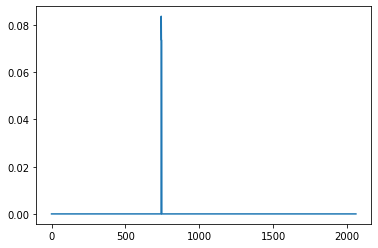

In [93]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))

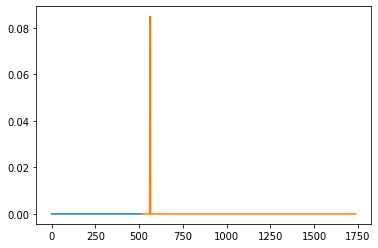

In [87]:
fig,ax = plt.subplots()
ax.plot(range(len(a)-1),list(a[1:]))
ax.plot(range(len(a),len(a)+len(b)),list(b))

In [88]:
b == b[94]

tensor([False, False, False,  ..., False, False, False])

In [55]:
np.where(b > b[500])

(array([837, 838, 839, 840, 841, 842, 843, 844, 845, 846, 847, 848]),)

In [71]:
(m.flag_list[848]) == (m.predection[848] > 0.5)

tensor([True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True, True, True, True, True, True, True, True, True,
        True, True, True, True])

In [74]:
c=0
for i in m.flag_list:
    c+=1
    if all(i != m.flag_list[500]):
        print(c)

1
2
3
4
5


# Model : Predective toggle lka

In [30]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(88).cuda()
        self.lka = torch.zeros(88).cuda()
        
        self.vis_compressor = nn.Sequential(nn.Linear(88*3,256*4),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(256*4,88))
        
        self.drop = nn.Dropout(0.1)
        self.flag_list = []
        
    
        self.previous_vis = torch.zeros(88).cuda()
        self.previous_states = torch.zeros(88).cuda()
        
        
        self.previous_states_conv = nn.Conv1d(2,1,(1))
    def forward(self,x):        
        input_list = x.view(160,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(160,-1)[vis_idx[0]][120:208]
        if lka_idx.size :
            print('hh')
            if self.lka[0]: 
                
                self.lka = torch.zeros(88).cuda()
            else:
                print('yes')
                self.lka = torch.ones(88).cuda()
            
            
        #Get the history of vis from previous vis and all the past frames
        history = self.previous_states_conv(torch.stack([self.previous_states,self.previous_vis]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        predected_vis = self.vis_compressor(self.drop(torch.cat([self.previous_vis,history,self.lka])))
        torch.sigmoid_(predected_vis)
        
        self.previous_vis = self.vis.detach().data
        self.previous_states = history.detach().data
        #self.previous_lka = self.lka.detach().cuda()
        
        return self.vis,predected_vis


In [31]:
m =  unet_seq(bs,seq_len).cuda()

In [32]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [33]:
trn_item = Validate(trn_dl)

In [34]:
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [35]:
learn.fit(m , opt , 1 , dl,loss  )

 37%|███▋      | 381/1023 [00:05<00:10, 59.61it/s, loss : 1.3125135366685121]

hh
yes


 98%|█████████▊| 250/255 [00:03<00:00, 64.67it/s, loss : 1.1827747802734374]  

train Loss:  1.217590570449829   validation loss:  1.1823689937591553
tensor(nan)


In [36]:
m.lka =torch.zeros(88).cuda()

In [37]:
trn_item.evaluate(model = m , crit = loss)

testing...


 37%|███▋      | 377/1023 [00:05<00:09, 65.41it/s]

hh
yes


100%|█████████▉| 1020/1023 [00:15<00:00, 67.65it/s]

In [38]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

  1%|          | 2/255 [00:00<00:13, 19.23it/s]

testing...


  0%|          | 2/608 [00:00<00:34, 17.72it/s]s]

testing...


  6%|▌         | 35/608 [00:00<00:14, 40.40it/s]

hh


 99%|█████████▉| 601/608 [00:09<00:00, 63.38it/s]

In [39]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

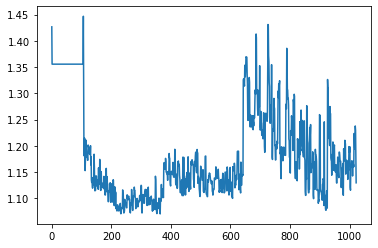

In [40]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))

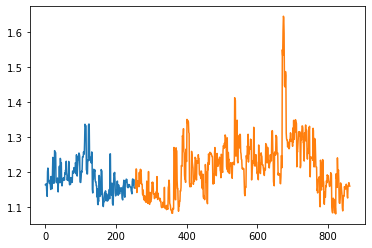

In [41]:
fig,ax = plt.subplots()
ax.plot(range(len(a)-1),list(a[1:]))
ax.plot(range(len(a),len(a)+len(b)),list(b))
#ax.plot(range(len(a)+len(b)), [a.max()+ a.max()*0.2]*(len(a)+len(b)))

In [42]:
path = 'Models/documentation/lka/vis given lka/1/ssim/'
save(path,[a,b,c],names=['normal','attack','train'])

In [43]:
cbs.save_all(path,model=m,learn=learn,opt=opt)

# Model : Predective toggle vis

In [73]:
class unet_seq(BaseModel):    
    def __init__(self,bs,seq_len):
        super().__init__()

        self._6ab = torch.FloatTensor([0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 1, 1])
        self._289 = torch.FloatTensor([0., 0., 1., 0., 1., 0., 0., 0., 1., 0., 0., 1., 0., 0., 0., 1., 0., 0.,
        0., 1., 1., 1., 0., 1., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 1., 1., 1.,
        1., 1., 1., 1., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.])
        #00 00 00 00 00 FF 20 00
        self.vis = torch.rand(88).cuda()
        self.lka = torch.zeros(88).cuda()
        
        self.lka_compressor = nn.Sequential(nn.Linear(88*4,256*4),
                                            nn.PReLU(),
                                            nn.Dropout(0.4),
                                            nn.Linear(256*4,88))
        
        self.drop = nn.Dropout(0.1)
        self.flag_list = []
        
    
        self.previous_lka = torch.zeros(88).cuda()
        self.previous_vis = torch.zeros(88).cuda()
        self.previous_states = torch.zeros(88).cuda()
        
        self.c = 0
        self.previous_states_conv = nn.Conv1d(2,1,(1))
    def forward(self,x):   
        self.c +=1
        input_list = x.view(160,-1).detach().cpu()
        vis_idx = np.where(((input_list[:,120:132] == self._6ab).sum(dim=1) // 12) == 1)[0]
        lka_idx = np.where(((input_list[:,120:120+88] == self._289).sum(dim=1) // 88) == 1)[0]
        if vis_idx.size :
            self.vis = x.view(160,-1)[vis_idx[0]][120:208]
        if lka_idx.size :
            print(self.c)
            if self.lka[0]: 
                self.lka = torch.zeros(88).cuda()
            else:
                print('yes')
                self.lka = torch.ones(88).cuda()
            
            
        #Get the history of vis from previous vis and all the past frames
        history = self.previous_states_conv(torch.stack([self.previous_states,self.previous_vis]).view(1,2,-1)).view(-1)
        history = self.drop(nn.functional.relu(history))
        predected_lka = self.lka_compressor(self.drop(torch.cat([self.vis,self.previous_vis,history,self.previous_lka])))
        torch.sigmoid_(predected_lka)
        
        self.previous_vis = self.vis.detach().data
        self.previous_states = history.detach().data
        self.previous_lka = self.lka.detach().cuda()
        
        return self.lka,predected_lka


In [74]:
m =  unet_seq(bs,seq_len).cuda()

In [75]:
opt = torch.optim.Adam(m.parameters(),1e-4)
opt = BaseOptimizer(opt)
learn = learner()

In [76]:
trn_item = Validate(trn_dl)

In [77]:
val2_item = Validate(v4_val_dl)
v4_anml_item = Validate(v4_anml_dl)

In [78]:
learn.fit(m , opt , 1 , dl,loss  )

 37%|███▋      | 377/1023 [00:05<00:09, 65.20it/s, loss : 695.034648541114]  

369
yes


 98%|█████████▊| 249/255 [00:03<00:00, 63.63it/s, loss : 1.0828330411489708]]

train Loss:  257.288818359375   validation loss:  1.0829427242279053
tensor(nan)


In [79]:
#m.load_state_dict(torch.load('Models/documentation/lka/predict lka given vis and past lka/1/BaseModel'))

In [63]:
m.lka = torch.zeros_like(m.lka).cuda()

In [64]:
trn_item.evaluate(model = m , crit = loss)

  0%|          | 0/1023 [00:00<?, ?it/s]

testing...


 37%|███▋      | 377/1023 [00:06<00:09, 65.52it/s]

1647
yes


100%|█████████▉| 1021/1023 [00:16<00:00, 68.83it/s]

In [80]:
val2_item.evaluate(model = m , crit = loss)
v4_anml_item.evaluate(model = m , crit = loss)

  0%|          | 0/255 [00:00<?, ?it/s]

testing...


  0%|          | 2/608 [00:00<00:30, 20.00it/s]s]

testing...


  5%|▌         | 33/608 [00:00<00:13, 43.32it/s]

1557


 99%|█████████▉| 604/608 [00:09<00:00, 63.99it/s]

In [66]:
a = torch.tensor(val2_item.test_loss)#.median() # Validation
b = torch.tensor(v4_anml_item.test_loss)#.median() # Anomaly 
c = torch.tensor(trn_item.test_loss)#.median() # Anomaly 

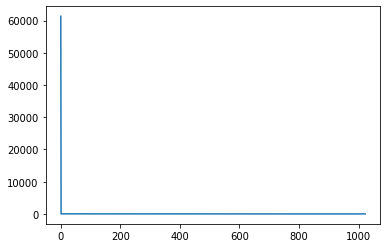

In [67]:
fig,ax = plt.subplots()
ax.plot(range(len(c)),list(c))


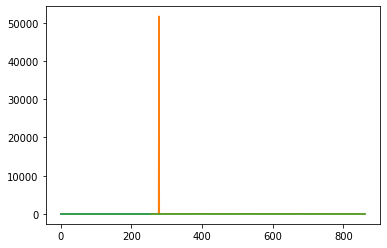

In [68]:
fig,ax = plt.subplots()
ax.plot(range(len(a)-1),list(a[1:]))
ax.plot(range(len(a),len(a)+len(b)),list(b))
ax.plot(range(len(a)+len(b)), [a.max()+ a.max()*0.2]*(len(a)+len(b)))

In [72]:
np.where(b>4000)

(array([23]),)

In [69]:
path = 'Models/documentation/lka/lka given vis/1/ssim/'
save(path,[a,b,c],names=['normal','attack','train'])

In [70]:
cbs.save_all(path,model=m,learn=learn,opt=opt)